In [20]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.experimental import StreamDecisionForest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb

In [21]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 1000000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [22]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


In [26]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden=(256, 128), p_dropout=0.2, use_sigmoid=True):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(p_dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        if use_sigmoid:           # keep preds in [0,1] if y is normalized
            layers += [nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)        # (N, 1)

def mse_loss(pred, target, eps=1e-12):
    # return torch.sqrt(nn.functional.mse_loss(pred, target) + eps)
    return nn.functional.mse_loss(pred, target)

def train_regressor(model, train_loader, val_loader, epochs=30, lr=1e-3, weight_decay=1e-4, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_tr = float("inf")
    best_val = float("inf")
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        tot_rmse, n_batches = 0.0, 0
        for xb, yb in train_loader:
            xb = xb.to(device).float()
            yb = yb.to(device).float().view(-1, 1)  # ensure (N,1)

            opt.zero_grad()
            preds = model(xb)
            loss = mse_loss(preds, yb)
            loss.backward()
            opt.step()

            tot_rmse += loss.item()
            n_batches += 1

        # validation
        model.eval()
        val_rmse, m = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device).float()
                yb = yb.to(device).float().view(-1, 1)
                preds = model(xb)
                val_rmse += mse_loss(preds, yb).item()
                m += 1
        val_rmse /= max(1, m)
        tr_rmse = tot_rmse / max(1, n_batches)
        if ep % 500 == 0:
            print(f"Epoch {ep:02d} | train MSE {tr_rmse:.6f} | val MSE {val_rmse:.6f}")

        if tr_rmse <= best_tr:
            if val_rmse <= best_val: ## Ignore the posibility of overfitting
                best_tr = tr_rmse
                best_val = val_rmse
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                print(f"Best Model: Epoch {ep:02d} | train MSE {tr_rmse:.6f} | val MSE {val_rmse:.6f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict(model, X):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        if isinstance(X, torch.Tensor):
            X_t = X.to(device).float()
        else:
            X_t = torch.from_numpy(np.asarray(X, dtype=np.float32)).to(device)
        preds = model(X_t).cpu().squeeze(1)
    return preds

In [ ]:
def train_model(X, Y, model= None, model_name = 'rf'):
    """Train or continue training the XGBRegressor."""
    if model is None:
        if model_name == 'rf':
            model = xgb.XGBRegressor(
                objective="reg:squarederror",
                tree_method="exact",
                n_jobs=-1,
                learning_rate=0.05, max_depth=10,
                subsample=1, colsample_bytree=0.8,
                n_estimators=1000, eval_metric="rmse"
            )
            model.fit(X, Y)
        elif model_name == 'nn':
            n = X.shape[0]
            tr_size = int(X.shape[1]*0.9)
            val_size = X.shape[1] - tr_size

            idx_val = np.random.choice(n, val_size, replace=False)
            idx_tr  = np.setdiff1d(np.arange(n), idx_val)
            
            X_train = X[idx_tr,:]
            Y_train = np.array(Y[idx_tr]).reshape(-1,1)
            X_val = X[idx_val,:]
            Y_val = np.array(Y[idx_val]).reshape(-1,1)
            if n <= 512:
                batch_size_train = 32
            elif 512<=n<= 1024:
                batch_size_train = 64
            else:
                batch_size_train = 128
            batch_size_val = val_size

            train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
            val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
            train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
            val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)
            model = MLPRegressor(input_dim=X_train.shape[1], hidden=(128,128), p_dropout=0.1, use_sigmoid=False)
            model = train_regressor(model, train_loader, val_loader, epochs=1000, lr=1e-2,weight_decay = 1e-4)
    return model

def predict_paths(model, df_paths, t_start, t_prime,model_name = 'nn'):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        cand_pe = position_encoder(df_paths.iloc[:,i], type="onehot")
        curr_time = t_start + 1 + i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe, time_emb])
        if model_name == 'nn':
            preds[:, i] = predict(model, features)
        else:
            preds[:, i] = model.predict(features)
    return preds

def choose_next_state(model, current_state, t_now, t_prime, gamma,model_name = 'nn'):
    """Pick best next state based on discounted rewards."""
    df_paths = enumerate_paths(x0=current_state, t_inital=t_now, t_prime=t_prime)
    preds = predict_paths(model, df_paths, t_now, t_prime,model_name = model_name)

    rewards_matrix = preds[:, 1:]   # ignore first col (current)
    discounts = gamma ** np.arange(1, t_prime+1)
    total_disc = (rewards_matrix * discounts).sum(axis=1)

    best_idx = np.argmax(total_disc)
    return int(df_paths.iloc[best_idx, 1]), df_paths, preds

def run_inference(model, start_state, T_p, t_prime, gamma, rewards_in_period,model_name):
    """Generate future trajectory and compute regret."""
    current_state = start_state
    future_states = [current_state]

    for delta_t in range(100):
        next_state, df_paths, preds = choose_next_state(model, current_state, T_p + delta_t, t_prime, gamma,model_name)
        future_states.append(next_state)
        current_state = next_state

    # compute rewards
    irewards_test = [reward_simulate(future_states[i], T_p+i, rewards_in_period) 
                     for i in range(1, len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test, 100, gamma)

    # optimal path benchmark
    path, ireward_opt = path_opt(future_states[0], T_p, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, gamma)

    pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100

    return pregret


T = 600
gamma = 0.5
t_prime = 6
DEALTA_t = 600
PREGRETS = []

for rep in range(10):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=5000,
        tdim=50, n_sessions=1, seed=515+rep
    )

    # initial dataset
    X_train = np.hstack([position_encoder(states[:T,0], type="onehot"), states[:T,1:]])
    Y_train = irewards[:T]
    model = train_model(X_train, Y_train,model_name = 'nn')

    PREGRET = []
    # --- online training ---
    current_state = states[T,0]
    for delta_t in range(DEALTA_t):
        next_state, df_paths, preds = choose_next_state(model, current_state, T+delta_t, t_prime, gamma,'nn')
        next_time = T+1+delta_t
        next_features = np.hstack([
            position_encoder(np.array([next_state]), type="onehot"),
            time_embedding_np(next_time, tdim=50).reshape(1,-1)
        ])
        next_reward = reward_simulate(next_state, next_time-1, rewards_in_period)

        X_train = np.vstack([X_train, next_features])
        Y_train = np.vstack([Y_train.reshape(-1,1), [[next_reward]]])
        # X_train = np.hstack([position_encoder(states[:T+delta_t,0], type="onehot"), states[:T+delta_t,1:]])
        # Y_train = irewards[:T+delta_t]
        model = train_model(X_train, Y_train, model_name = 'nn')
        current_state = next_state  # move forward

    
        T_p = delta_t + T
        start_state = current_state
        pregret_val = run_inference(model, start_state, T_p, t_prime, gamma, rewards_in_period,'nn')
        print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)
    np.savez(
        f"../results/OnlinePAFM/PAFM_NN_online_gamma0.9_oh_w_time200_800_lookahead{6}_reps{rep}.npz",
        pregrets_online = PREGRET,
        )
    plt.figure(figsize=(15, 6))
    plt.plot(np.arange(200,1000),PREGRET)
    plt.yticks([0,0.5,1,1.5,2,2.5])
    plt.show()

    PREGRETS.append(PREGRET)


Best Model: Epoch 01 | train MSE 3.182625 | val MSE 0.236712
Best Model: Epoch 02 | train MSE 2.492310 | val MSE 0.133366
Best Model: Epoch 06 | train MSE 0.421531 | val MSE 0.048241
Best Model: Epoch 07 | train MSE 0.367594 | val MSE 0.040785
Best Model: Epoch 18 | train MSE 0.241939 | val MSE 0.036815
Best Model: Epoch 19 | train MSE 0.071755 | val MSE 0.032097
Best Model: Epoch 63 | train MSE 0.051440 | val MSE 0.022123
Epoch 500 | train MSE 0.327142 | val MSE 0.028445
Best Model: Epoch 569 | train MSE 0.048600 | val MSE 0.010792
Epoch 1000 | train MSE 0.277148 | val MSE 0.207299
Best Model: Epoch 01 | train MSE 6.969139 | val MSE 0.165040
Best Model: Epoch 02 | train MSE 2.144467 | val MSE 0.023252
Best Model: Epoch 04 | train MSE 1.085901 | val MSE 0.011986
Best Model: Epoch 05 | train MSE 0.674021 | val MSE 0.002059
Best Model: Epoch 41 | train MSE 0.146009 | val MSE 0.001451
Best Model: Epoch 48 | train MSE 0.122146 | val MSE 0.001164


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_26614/1196059455.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  preds[:, i] = predict(model, features)


Epoch 500 | train MSE 0.256036 | val MSE 0.012164
Epoch 1000 | train MSE 0.070396 | val MSE 0.007392
rep 0, T_train 200, pregret=1.1441
Best Model: Epoch 01 | train MSE 2.932461 | val MSE 0.438346
Best Model: Epoch 02 | train MSE 2.438461 | val MSE 0.330591
Best Model: Epoch 03 | train MSE 2.303960 | val MSE 0.041449
Best Model: Epoch 10 | train MSE 1.751178 | val MSE 0.011632
Best Model: Epoch 46 | train MSE 0.036090 | val MSE 0.004020
Epoch 500 | train MSE 0.097131 | val MSE 0.173825
Epoch 1000 | train MSE 0.108554 | val MSE 0.196196
rep 0, T_train 201, pregret=0.9739
Best Model: Epoch 01 | train MSE 5.556429 | val MSE 0.394543
Best Model: Epoch 07 | train MSE 0.995261 | val MSE 0.070614
Best Model: Epoch 72 | train MSE 0.248740 | val MSE 0.068038
Epoch 500 | train MSE 0.166472 | val MSE 1.692252
Epoch 1000 | train MSE 0.120712 | val MSE 1.368551
rep 0, T_train 202, pregret=0.9589
Best Model: Epoch 01 | train MSE 3.631960 | val MSE 0.705968
Best Model: Epoch 07 | train MSE 0.552685 |

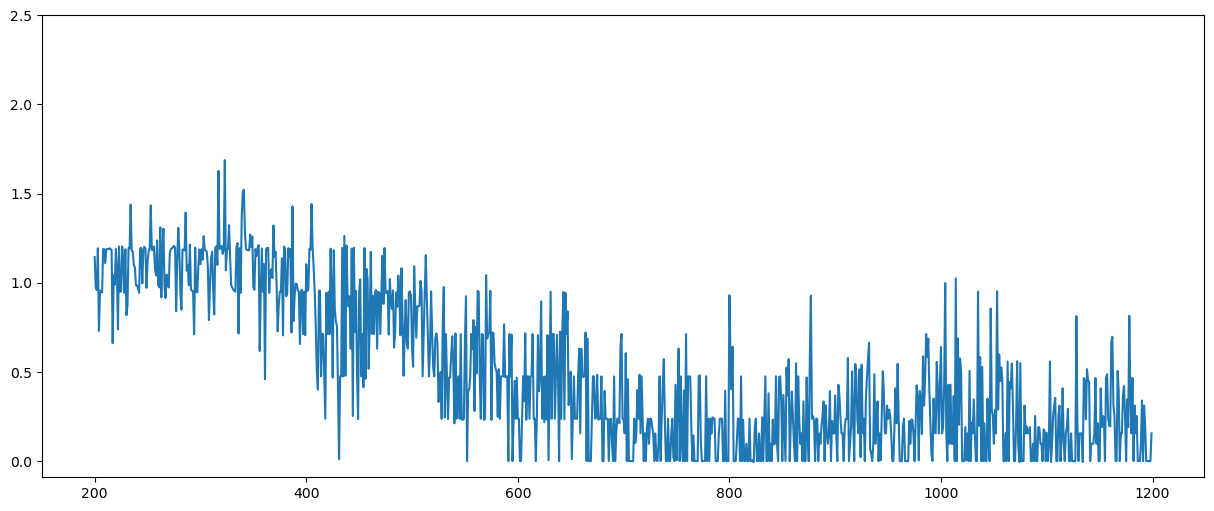

In [46]:
plt.figure(figsize=(15, 6))
plt.plot(np.arange(200,1200),PREGRET[:1000])
plt.yticks([0,0.5,1,1.5,2,2.5])
PREGRETS_arr = np.vstack(PREGRETS)
# PREGRETS_random_arr = np.vstack(PREGRETS_random)
# np.savez(
#     f"../results/OnlinePAFM/PAFM_NN_online_gamma0.9_oh_w_time200_800_lookahead{6}_reps{1}.npz",
#     pregrets_online = PREGRET,
#     )

In [44]:
X_train = X_train[:800]
Y_train = Y_train[:800]
T = 200
for delta_t in np.arange(600,1000):
    next_state, df_paths, preds = choose_next_state(model, current_state, T+delta_t, t_prime, gamma,'nn')
    next_time = T+1+delta_t
    next_features = np.hstack([
        position_encoder(np.array([next_state]), type="onehot"),
        time_embedding_np(next_time, tdim=50).reshape(1,-1)
    ])
    next_reward = reward_simulate(next_state, next_time-1, rewards_in_period)

    X_train = np.vstack([X_train, next_features])
    Y_train = np.vstack([Y_train.reshape(-1,1), [[next_reward]]])
    # X_train = np.hstack([position_encoder(states[:T+delta_t,0], type="onehot"), states[:T+delta_t,1:]])
    # Y_train = irewards[:T+delta_t]
    model = train_model(X_train, Y_train, model_name = 'nn')
    current_state = next_state  # move forward

    T_p = delta_t + T
    start_state = current_state
    pregret_val = run_inference(model, start_state, T_p, t_prime, gamma, rewards_in_period,'nn')
    print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
    PREGRET.append(pregret_val)

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_26614/1196059455.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  preds[:, i] = predict(model, features)


Best Model: Epoch 01 | train MSE 6.249312 | val MSE 5.455627
Best Model: Epoch 03 | train MSE 2.077835 | val MSE 1.954974
Best Model: Epoch 05 | train MSE 0.924378 | val MSE 0.251163
Best Model: Epoch 25 | train MSE 0.273533 | val MSE 0.129434
Best Model: Epoch 31 | train MSE 0.136670 | val MSE 0.069113
Best Model: Epoch 95 | train MSE 0.135308 | val MSE 0.040344
Best Model: Epoch 148 | train MSE 0.131955 | val MSE 0.028735
Best Model: Epoch 179 | train MSE 0.074891 | val MSE 0.020739
Best Model: Epoch 221 | train MSE 0.066320 | val MSE 0.016503
Best Model: Epoch 237 | train MSE 0.060657 | val MSE 0.014610
Best Model: Epoch 347 | train MSE 0.059377 | val MSE 0.008987
Best Model: Epoch 358 | train MSE 0.048269 | val MSE 0.006467
Best Model: Epoch 364 | train MSE 0.045892 | val MSE 0.000576
Epoch 500 | train MSE 0.046913 | val MSE 0.018510
Best Model: Epoch 725 | train MSE 0.034117 | val MSE 0.000473
Epoch 1000 | train MSE 0.095384 | val MSE 0.010152
rep 0, T_train 800, pregret=0.0000
Be

([<matplotlib.axis.YTick at 0x370101930>,
 [Text(0, 0.0, '0.0'),
  Text(0, 0.5, '0.5'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.5, '1.5'),
  Text(0, 2.0, '2.0'),
  Text(0, 2.5, '2.5')])

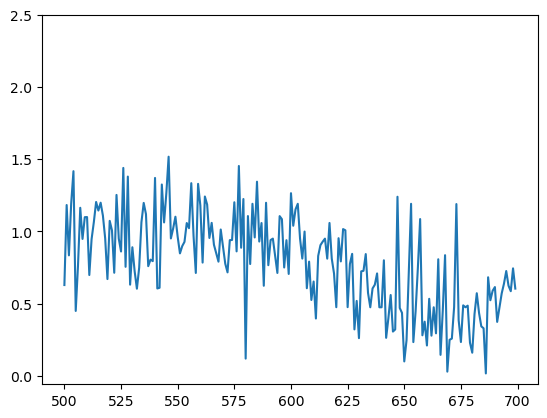

In [31]:
plt.plot(np.arange(500,700),PREGRET)
plt.yticks([0,0.5,1,1.5,2,2.5])